## Statistical Power

*The goal of this notebook is to understand what statistical power is, how to compute it, and how it gets used to plan and to cancel real experiments.*

We want to consider an A/B testing example: a website with two display formats, where we care about the **average order value (AOV)** each format produces. A is the current website that is in production, and we want to test format B because our hypothesis is that it will generate a higher average order value. 

Along the way we will answer some questions:

1. If there really is a difference, how often would our test actually find it?
2. How long do we need to run the test?
3. Given the traffic we actually have, what is the smallest effect we could ever detect?

## Problem Setup

In [2]:
# Let's start with standard imports, plus the power tools from statsmodels.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from statsmodels.stats.power import TTestIndPower, NormalIndPower
from statsmodels.stats.proportion import proportion_effectsize

sns.set_theme(style="whitegrid")

# A single random number generator so the notebook is reproducible.
rng = np.random.default_rng(6021)

In [3]:
# We need to know where we sit currently for this to be test to be meaningful. 
# Often, this information is given to data scientists from business analysts or other partners. 

MEAN_AOV       = 50.00   # average order value under the current design ("A"), in dollars. This is often known/calculated from historical data.
SD_AOV         = 30.00   # standard deviation of order value. Again, this is often known/calculated from historical data.

# Now let's make some assumptions about the new design ("B") and the test we want to run.
TRUE_LIFT      = 0.05    # For purposes of this exercise, we are going to say that the new design ("B") really is 5% better. 
DAILY_PER_ARM  = 200     # # of visitors we route to A and B each day. 
ALPHA          = 0.05    # our significance level -- this is a standard (if arbitrary) choice. 

MEAN_B = MEAN_AOV * (1 + TRUE_LIFT)

print(f"Design A: ${MEAN_AOV:.2f}   Design B: ${MEAN_B:.2f}   difference: ${MEAN_B - MEAN_AOV:.2f}")

Design A: $50.00   Design B: $52.50   difference: $2.50


### A note about traffic going to A and B

In practice, if A is the current webpage that is in production, we won't consider every single user going to A. We will need to select a appropriately randomly selected control group for the DAILY_PER_ARM. This can be a challenge both from a statistical and engineering perspective. For purposes of this exercise, we will assume that we surmounted these challenges. We must also ensure that the group of users seeing webpage B is appropriately randomly selected. 


## Experiments 

Let's simulate a three day experiment: Let's pretend we are running this test for three days at 200 visitors per arm per day. This means after three days we will have 600 observations in this group. If we were at a real company, we would collect this data, but since we are in a class we are going to simulate it. 

*Note*: We defined a 5% difference between A and B above. So we KNOW the null hypothesis is false. In reality, we might say something like: 

"Our expectation based on past experiments is that B will give us a 5% lift in average order value. We'd like to test that this is really happening before we swap out A for B for our entire customer population." 

OR 

"This will only meaningfully increase our revenue if we see a 5% lift in AOV, otherwise it isn't worth the cost it will take us to make this switch for all customers. Can we run an experiment to see if we actually are getting a 5% increase?" 

In [4]:
# Function to simulate one A/B test

def run_one_experiment(n_per_arm, mean_a=MEAN_AOV, mean_b=MEAN_B, sd=SD_AOV, generator=rng):
    """Simulate one A/B test and return (observed difference in means, p-value)."""
    a = generator.normal(mean_a, sd, n_per_arm)
    b = generator.normal(mean_b, sd, n_per_arm)
    t_stat, p_value = stats.ttest_ind(b, a, equal_var=False)
    return b.mean() - a.mean(), p_value



In [5]:
# Now that we have a reusable function, let's run a three-day A/B test and run Welch's t-test
# Note: If we had a different random seed above, we would get a different result. 
N_THREE_DAYS = 3 * DAILY_PER_ARM

observed_diff, p_value = run_one_experiment(N_THREE_DAYS, mean_a=MEAN_AOV, mean_b=MEAN_B, sd=SD_AOV, generator=rng)
print(f"n per arm:            {N_THREE_DAYS}")
print(f"observed difference:  ${observed_diff:.2f}  ({observed_diff / MEAN_AOV:.1%} lift)")
print(f"p-value:              {p_value:.4f}")
print(f"significant at 0.05?  {p_value < ALPHA}")

n per arm:            600
observed difference:  $0.15  (0.3% lift)
p-value:              0.9303
significant at 0.05?  False


Concluded:
- theres no signficance difference
- 

In [6]:
# That was one experiment and it is telling us that there is no significant observed difference between A and B. 
# Nothing about that particular experiment was special. Let's run ten more experiments.

print(f"{'run':>4}  {'observed lift':>14}  {'p-value':>9}  significant?")
for i in range(1, 11):
    diff, p = run_one_experiment(N_THREE_DAYS, generator=rng)
    print(f"{i:>4}  {diff / MEAN_AOV:>13.1%}  {p:>9.4f}  {'YES' if p < ALPHA else 'no'}")

 run   observed lift    p-value  significant?
   1          -2.9%     0.3911  no
   2          11.4%     0.0010  YES
   3          11.3%     0.0014  YES
   4           8.7%     0.0100  YES
   5           0.6%     0.8517  no
   6           7.2%     0.0382  YES
   7           6.5%     0.0669  no
   8          12.2%     0.0005  YES
   9          13.6%     0.0001  YES
  10           1.2%     0.7231  no


Concluded:
- if i ran this test for three days it is not useful (not long enough)

Remember that we know that **he true lift from B is 5% in every single row** but the observed lift varies wildly in a three day test.

Observations: 
* If we only ran this test for three days, we could not reliably conclude that there was a 5% effect. 
* If we were looking for a 5% effect and ran this test for three days, our conclusion would vary. If we ran the test once and saw an insignficant value, we might conclude there was not a meaningful effect. 

Questions:
* How long would we need to run the test to reliably detect 5%?
* What if the effect size was larger? What if it was smaller?

## Relating Power to our above simulations

We (hopefully) just convinced ourselves that a 3-day test is not necessarily going to allow us to conclude there is a 5% difference between A and B

What is the statistical power here? 

Remember from the slides that **statistical power** is the probability that a test rejects the null hypothesis, *given that the
null hypothesis is actually false.* It is one minus the Type II error rate.

|                          | $H_0$ is true       | $H_0$ is false        |
|--------------------------|---------------------|-----------------------|
| **We reject $H_0$**      | Type I error ($\alpha$) | Correct — **power** ($1-\beta$) |
| **We fail to reject**    | Correct             | Type II error ($\beta$) |

We can again estimate this through simulation: run this experiment many times and count how often we reject the null hypothesis.

In [7]:
# Estimate power by brute force: run the experiment thousands of times and count rejections.

def simulate_power(n_per_arm, mean_a=MEAN_AOV, mean_b=MEAN_B, sd=SD_AOV,
                   alpha=ALPHA, n_sims=10000, generator=rng):
    """Fraction of simulated experiments that reach significance."""
    a = generator.normal(mean_a, sd, (n_sims, n_per_arm))
    b = generator.normal(mean_b, sd, (n_sims, n_per_arm))
    _, p_values = stats.ttest_ind(b, a, axis=1, equal_var=False)
    return (p_values < alpha).mean()

N_SIMS = 10000
power_three_days = simulate_power(N_THREE_DAYS, n_sims=N_SIMS)
monte_carlo_se = np.sqrt(power_three_days * (1 - power_three_days) / N_SIMS)

print(f"Power of the three-day test: {power_three_days:.1%}  (+/- {monte_carlo_se:.1%} simulation error)")
print(f"So we miss a real 5% lift about {1 - power_three_days:.0%} of the time.")

Power of the three-day test: 29.8%  (+/- 0.5% simulation error)
So we miss a real 5% lift about 70% of the time.


concluded:
- 30% is a lower stat power meaning that the other 70% is a high error event

About 30%. **We would have been more likely to miss the effect than to find it.**

Because Power = 1 - $\beta$, and $\beta$ is the probability of a Type II error, this means the probability of a Type II error for this particular example is pretty high!

In [8]:
# Luckily for us, statsmodels computes the same quantity without simulating.
# Note: The effect size for a two-sample t-test is Cohen's d: the difference in means, in SDs.

cohens_d = (MEAN_B - MEAN_AOV) / SD_AOV

# NOTE: We are creating an instance of the class TTestIndPower that we will use subequently
# Documentation: https://www.statsmodels.org/stable/generated/statsmodels.stats.power.TTestIndPower.html
analysis = TTestIndPower()

analytic_power = analysis.power(effect_size=cohens_d, nobs1=N_THREE_DAYS,
                                alpha=ALPHA, ratio=1.0, alternative="two-sided")

print(f"Cohen's d            = {cohens_d:.4f}   (a $2.50 difference against a $30 SD)")
print(f"power by simulation  = {power_three_days:.4f}  (+/- {monte_carlo_se:.4f})")
print(f"power by statsmodels = {analytic_power:.4f}")

Cohen's d            = 0.0833   (a $2.50 difference against a $30 SD)
power by simulation  = 0.2980  (+/- 0.0046)
power by statsmodels = 0.3027


### Now let's look at how power will vary if we make some adjustments

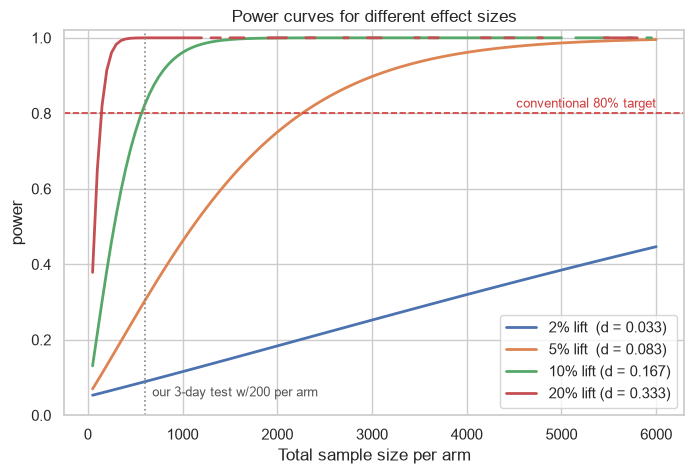

In [9]:
# Power curves: how power grows with sample size, for several true effect sizes.

n_grid = np.arange(50, 6001, 50)
effect_sizes = {
    "2% lift  (d = 0.033)": 0.02 * MEAN_AOV / SD_AOV,
    "5% lift  (d = 0.083)": 0.05 * MEAN_AOV / SD_AOV,
    "10% lift (d = 0.167)": 0.10 * MEAN_AOV / SD_AOV,
    "20% lift (d = 0.333)": 0.20 * MEAN_AOV / SD_AOV,
}

fig, ax = plt.subplots(figsize=(8, 5))
for label, d in effect_sizes.items():
    ax.plot(n_grid, analysis.power(effect_size=d, nobs1=n_grid, alpha=ALPHA, ratio=1.0),
            linewidth=2, label=label)

ax.axhline(0.80, color="#d03b3b", linestyle="--", linewidth=1.2)
ax.text(6000, 0.815, "conventional 80% target", ha="right", color="#d03b3b", fontsize=9)
ax.axvline(N_THREE_DAYS, color="#898781", linestyle=":", linewidth=1.2)
ax.text(N_THREE_DAYS + 80, 0.05, "our 3-day test w/200 per arm", color="#555555", fontsize=9)

ax.set_xlabel("Total sample size per arm")
ax.set_ylabel("power")
ax.set_ylim(0, 1.02)
ax.set_title("Power curves for different effect sizes")
ax.legend(loc="lower right")
plt.show()

what might you suggest:
- how long can the test be?
    - how many test we can do


### How long should we run these simulations? 

We can estimate from the above chart, or we can leverage our friend stats models. 
This is the calculation that actually gets done in practice. We fix the effect we care about, fix $\alpha$, fix the power we want, and solve for $n$.

In [10]:
# Solve for the sample size needed to detect a 5% lift with 80% power.

n_required = analysis.solve_power(effect_size=cohens_d, alpha=ALPHA,
                                  power=0.80, ratio=1.0, alternative="two-sided")
n_required = int(np.ceil(n_required))
days_required = n_required / DAILY_PER_ARM

print(f"Users needed per arm: {n_required:,}")
print(f"Total users needed:   {2 * n_required:,}")
print(f"At {DAILY_PER_ARM} per arm per day, that is {days_required:.1f} days.")
print()
print(f"We ran the test for 3 days. We needed about {np.ceil(days_required):.0f}.")

Users needed per arm: 2,262
Total users needed:   4,524
At 200 per arm per day, that is 11.3 days.

We ran the test for 3 days. We needed about 12.


In [11]:
# What if we had the ability to include 500 users per arm per day? 

n_required = analysis.solve_power(effect_size=cohens_d, alpha=ALPHA,
                                  power=0.80, ratio=1.0, alternative="two-sided")
n_required = int(np.ceil(n_required))
days_required = n_required / 500 # <-- We are replacing the daily users per arm with 500 (up from 200)

print(f"Users needed per arm: {n_required:,}")
print(f"Total users needed:   {2 * n_required:,}")
print(f"At 500 per arm per day, that is {days_required:.1f} days.")
print()
print(f"We ran the test for 3 days. We needed about {np.ceil(days_required):.0f}.")

Users needed per arm: 2,262
Total users needed:   4,524
At 500 per arm per day, that is 4.5 days.

We ran the test for 3 days. We needed about 5.


### If we have a fixed length of time we can run, what effect could we reasonably detect?

So far, we have framed this problem assuming a 5% lift and seeing what levers we could pull to detect it. Now let's think about a fixed time for running an experiment--what is the minimum effect size we could detect? 

In [12]:
# Solve for effect size instead of sample size: the MDE.

# Note--we are asuming our variables from the beginning:
# alpha = 0.05
# DAILY_PER_ARM=200
# Mean and standard deviation of 50/30 respectively. 

def mde_for_n(n_per_arm, power=0.80, alpha=ALPHA):
    """Smallest Cohen's d detectable at the given power, converted to a % lift in AOV."""
    d = analysis.solve_power(effect_size=None, nobs1=n_per_arm, alpha=alpha,
                             power=power, ratio=1.0, alternative="two-sided")
    return d * SD_AOV / MEAN_AOV



In [13]:
rows = []
for days in [3, 5, 7, 10, 14, 21, 28]:
    n = days * DAILY_PER_ARM
    rows.append({"days": days, "n per arm": n, "MDE (relative lift)": mde_for_n(n)})

mde_table = pd.DataFrame(rows)
mde_table["MDE (relative lift)"] = mde_table["MDE (relative lift)"].map("{:.1%}".format)
mde_table

,days,n per arm,MDE (relative lift)
0,3,600,9.7%
1,5,1000,7.5%
2,7,1400,6.4%
3,10,2000,5.3%
4,14,2800,4.5%
5,21,4200,3.7%
6,28,5600,3.2%


In [14]:
rows = []
for days in [3, 5, 7, 10, 14, 21, 28]:
    n = days * 500
    rows.append({"days": days, "n per arm": n, "MDE (relative lift)": mde_for_n(n)})

mde_table = pd.DataFrame(rows)
mde_table["MDE (relative lift)"] = mde_table["MDE (relative lift)"].map("{:.1%}".format)
mde_table

,days,n per arm,MDE (relative lift)
0,3,1500,6.1%
1,5,2500,4.8%
2,7,3500,4.0%
3,10,5000,3.4%
4,14,7000,2.8%
5,21,10500,2.3%
6,28,14000,2.0%
